In [1]:
import pandas as pd

In [ ]:
#pip install scikit-learn==1.0.0
#pip install statsmodels==0.12.2

In [2]:
#from nsepy import get_history as gh
import datetime as dt

In [3]:
start = dt.datetime(2021,7,1)
end = dt.datetime(2022,1,28)
#stk_data = gh(symbol='TATACOFFEE',start=start,end=end)
df = pd.read_csv("Tatacoffee13_21.csv", index_col='Date', parse_dates=True)


In [4]:
stk_data= df.loc[start:end]

In [5]:
stk_data

,Open,High,Low,Close
Date,,,,
2021-07-01,188.60,189.00,183.00,184.55
2021-07-02,183.05,187.50,182.15,186.40
2021-07-05,187.85,198.35,187.85,192.45
2021-07-06,193.80,194.80,187.35,188.80
2021-07-07,187.80,193.95,185.40,192.85
...,...,...,...,...
2021-12-22,202.90,207.80,201.35,205.00
2021-12-23,206.00,206.85,202.05,202.95
2021-12-24,203.90,203.90,199.35,201.00


In [ ]:
#stk_data=stk_data[["Open","High","Low","Close"]]


In [ ]:
#stk_data

In [6]:
column="Close"

In [7]:
from sklearn.preprocessing import MinMaxScaler  #importing library for normalizing the data. In Time series we need to use MinMaxScaler. in TSA we are using Univariate data. So, there is no separate column for prediction. We will predict the value in same column
Ms = MinMaxScaler() # Assinging the algorithm to a varaiable
data1= Ms.fit_transform(stk_data[[column]]) # Converting the original data into standardize value
print("Shape of dataset:",data1.shape)  

Shape of dataset: (123, 1)


In [8]:
len(data1)

123

In [9]:
data1

array([[0.05268022],
       [0.08687616],
       [0.1987061 ],
       [0.13123845],
       [0.20609982],
       [0.16173752],
       [0.15157116],
       [0.09057301],
       [0.19408503],
       [0.19408503],
       [0.19316081],
       [0.15804067],
       [0.13678373],
       [0.04990758],
       [0.31977819],
       [0.49260628],
       [0.62476895],
       [0.99075786],
       [0.61737523],
       [0.55083179],
       [0.56931608],
       [0.55452865],
       [0.46303142],
       [0.57948244],
       [0.5064695 ],
       [0.56377079],
       [0.48428835],
       [0.39186691],
       [0.27356747],
       [0.40573013],
       [0.45101664],
       [0.37430684],
       [0.34750462],
       [0.33733826],
       [0.13863216],
       [0.        ],
       [0.2754159 ],
       [0.31885397],
       [0.26340111],
       [0.24491682],
       [0.31885397],
       [0.58133087],
       [0.54343808],
       [0.51386322],
       [0.47874307],
       [0.41404806],
       [0.56839187],
       [0.558

In [38]:
# Splitting data into Train and Test.
# This is univariate analysis. And also analysing the data in series not random.
# Split should happen in series like first set of records in train and rest set of records in test.
training_size = round(len(data1 ) * 0.80) # identifying the 80% of total records
print(training_size)  
X_train=data1[:training_size]  # assigning the first 80% records into X_train
X_test=data1[training_size:] # assigning the rest of 20% records into X_test
print("X_train length:",X_train.shape)
print("X_test length:",X_test.shape)
y_train=data1[:training_size] # Same X assignment need to do to Y as well. assigning the first 80% records into y_train
y_test=data1[training_size:] # assigning the rest of 20% records into y_test
print("y_train length:",y_train.shape)
print("y_test length:",y_test.shape)

98
X_train length: (98, 1)
X_test length: (25, 1)
y_train length: (98, 1)
y_test length: (25, 1)


In [11]:
from sklearn.metrics import root_mean_squared_error  # In TSA we will evaluate mean_squared_error. And closer to 0 would be good model
from statsmodels.tsa.ar_model import AutoReg  # In TSA libraries will be in statsmodel.tst.ar_model. And AutoReg will be Algorithm.

# in AutoReg  there are 2 playable parameters (hyper parameters). one is trend and another one is lags
trends=['n','t','c','ct']  
lags=[1,2,3,4]

for i in lags: #loop for hyper parameter lags
    #print(i)
   
    for td in trends: # loop for hyper paramer trends
        
        #print(td)
        #trendslist.append(td)
        model = AutoReg(X_train, lags=i,trend=td)  # Assigning the model into a varaiable
        model_fit = model.fit()  # Train the model
        # make prediction
        y_pred= model_fit.predict(len(X_train), len(data1)-1)  # predict the value start from last record of training data to last record of the dataset
        #print(y_pred)
        #mse=mean_squared_error(y_test,y_pred,squared=False)
        from stockFunctions import rmsemape   # calling user defined function
        print("Lag={},Trend={}".format(i,td)) 
        rmsemape(y_test,y_pred)  # passing original test value and predicted test value
        print("************")

Lag=1,Trend=n
RMSE-Testset: 0.14697833103051713
maPe-Testset: 0.2996233676581957
************
Lag=1,Trend=t
RMSE-Testset: 0.4527171307719543
maPe-Testset: 1.0040447397480157
************
Lag=1,Trend=c
RMSE-Testset: 0.14430244276422075
maPe-Testset: 0.29967659862124923
************
Lag=1,Trend=ct
RMSE-Testset: 0.3174617978940569
maPe-Testset: 0.708971452262302
************
Lag=2,Trend=n
RMSE-Testset: 0.1475578983263807
maPe-Testset: 0.30117919787413955
************
Lag=2,Trend=t
RMSE-Testset: 0.46227936478853554
maPe-Testset: 1.0271399304412832
************
Lag=2,Trend=c
RMSE-Testset: 0.14264674371339237
maPe-Testset: 0.29649421032977913
************
Lag=2,Trend=ct
RMSE-Testset: 0.3249526756000262
maPe-Testset: 0.7272668466791437
************
Lag=3,Trend=n
RMSE-Testset: 0.1740015880402995
maPe-Testset: 0.365595357275863
************
Lag=3,Trend=t
RMSE-Testset: 0.45770841309299315
maPe-Testset: 1.0176390425865733
************
Lag=3,Trend=c
RMSE-Testset: 0.1509596370778764
maPe-Testset: 0

In [12]:
len(y_pred)

25

In [13]:
from sklearn.metrics import root_mean_squared_error
rmse = root_mean_squared_error(y_test,y_pred)

print("RMSE-Testset:",rmse)


RMSE-Testset: 0.32309485027297474


In [14]:
y_test

array([[0.64510166],
       [0.64695009],
       [0.487061  ],
       [0.3271719 ],
       [0.3909427 ],
       [0.42144177],
       [0.43715342],
       [0.41866913],
       [0.3844732 ],
       [0.56746765],
       [0.58780037],
       [0.57486137],
       [0.64232902],
       [0.6090573 ],
       [0.57763401],
       [0.54343808],
       [0.48243993],
       [0.4168207 ],
       [0.23752311],
       [0.33179298],
       [0.43068392],
       [0.39279113],
       [0.35674677],
       [0.67744917],
       [0.56654344]])

In [15]:
y_pred

array([0.67922426, 0.67031807, 0.6968685 , 0.71721858, 0.72899563,
       0.74264325, 0.75365199, 0.76173777, 0.7689355 , 0.77512807,
       0.78049273, 0.78551103, 0.79030804, 0.79497148, 0.79960488,
       0.80424338, 0.80890056, 0.8135866 , 0.81830022, 0.82303632,
       0.82779021, 0.83255691, 0.83733213, 0.84211274, 0.84689646])

In [16]:
import numpy as np

error = np.abs(y_test - y_pred)
print("Mean error:", np.mean(error))

Mean error: 0.2938636796868245


In [17]:
from sklearn.metrics import mean_absolute_percentage_error
print("maPe-Testset:",mean_absolute_percentage_error(y_test,y_pred))
#print("mape-Trainset:",mean_absolute_percentage_error(y_Train,predicted_stock_price_train_ori))

maPe-Testset: 0.7209275552097273


In [18]:
i=1
td='n'
model = AutoReg(X_train, lags=i,trend=td)
model_fit = model.fit()
# make prediction
y_pred= model_fit.predict(len(X_train), len(data1)-1)
#print(y_pred)
from sklearn.metrics import r2_score
rmse=root_mean_squared_error(y_test,y_pred)
from stockFunctions import rmsemape
print("Lag={},Trend={}".format(i,td))
rmsemape(y_test,y_pred)
print("************")

Lag=1,Trend=n
RMSE-Testset: 0.14697833103051713
maPe-Testset: 0.2996233676581957
************


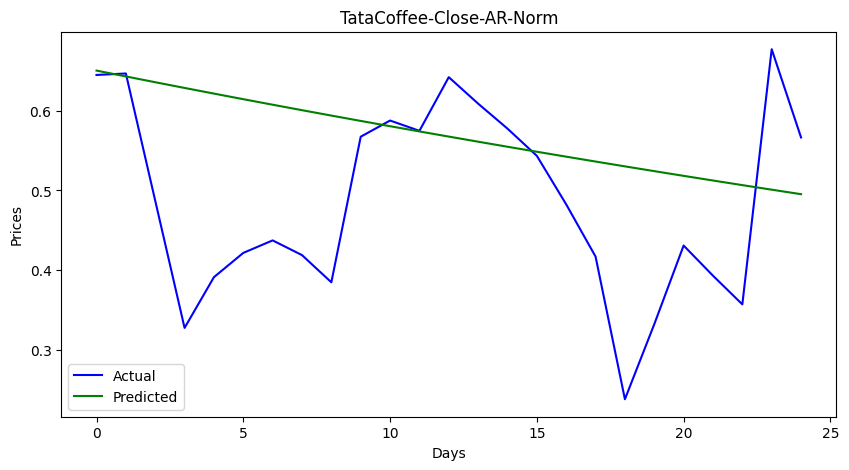

In [19]:
from stockFunctions import graph
graph(y_test,y_pred,"Actual","Predicted","TataCoffee-Close-AR-Norm","Days","Prices")

In [20]:
len(data1)

123

In [21]:
y_test

array([[0.64510166],
       [0.64695009],
       [0.487061  ],
       [0.3271719 ],
       [0.3909427 ],
       [0.42144177],
       [0.43715342],
       [0.41866913],
       [0.3844732 ],
       [0.56746765],
       [0.58780037],
       [0.57486137],
       [0.64232902],
       [0.6090573 ],
       [0.57763401],
       [0.54343808],
       [0.48243993],
       [0.4168207 ],
       [0.23752311],
       [0.33179298],
       [0.43068392],
       [0.39279113],
       [0.35674677],
       [0.67744917],
       [0.56654344]])

In [22]:
from stockFunctions import conversionSingle
aTestNormTable=conversionSingle(y_test,[column])

In [23]:
aTestNormTable

,Close
0,0.645102
1,0.64695
2,0.487061
3,0.327172
4,0.390943
5,0.421442
6,0.437153
7,0.418669
8,0.384473
9,0.567468


In [24]:
actual_stock_price_test_ori=Ms.inverse_transform(aTestNormTable)

In [25]:
actual_stock_price_test_ori

array([[216.6 ],
       [216.7 ],
       [208.05],
       [199.4 ],
       [202.85],
       [204.5 ],
       [205.35],
       [204.35],
       [202.5 ],
       [212.4 ],
       [213.5 ],
       [212.8 ],
       [216.45],
       [214.65],
       [212.95],
       [211.1 ],
       [207.8 ],
       [204.25],
       [194.55],
       [199.65],
       [205.  ],
       [202.95],
       [201.  ],
       [218.35],
       [212.35]])

In [26]:
actual_stock_price_test_oriA=conversionSingle(actual_stock_price_test_ori,[column])

In [27]:
actual_stock_price_test_oriA

,Close
0,216.6
1,216.7
2,208.05
3,199.4
4,202.85
5,204.5
6,205.35
7,204.35
8,202.5
9,212.4


In [28]:
from stockFunctions import conversionSingle
aTestNormTable=conversionSingle(y_test,[column])
actual_stock_price_test_ori=Ms.inverse_transform(aTestNormTable)
actual_stock_price_test_oriA=conversionSingle(actual_stock_price_test_ori,[column])

In [29]:
from stockFunctions import conversionSingle
pTestNormTable=conversionSingle(y_pred,[column])
predicted_stock_price_test_ori=Ms.inverse_transform(pTestNormTable)
predicted_stock_price_test_oriP=conversionSingle(predicted_stock_price_test_ori,[column])

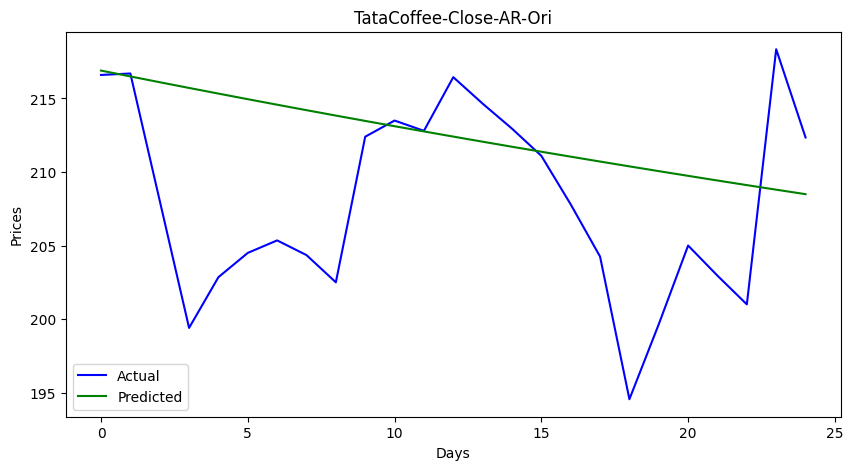

In [30]:
from stockFunctions import graph
graph(actual_stock_price_test_oriA,predicted_stock_price_test_oriP,"Actual","Predicted","TataCoffee-Close-AR-Ori","Days","Prices")

In [31]:
from stockFunctions import rmsemape
rmsemape(actual_stock_price_test_oriA,predicted_stock_price_test_oriP)

RMSE-Testset: 7.951527708750984
maPe-Testset: 0.030702745226223627


In [32]:
forecast=model_fit.predict(len(data1), len(data1)+3)

In [33]:
forecast

array([0.48964812, 0.4841131 , 0.47864065, 0.47323006])

In [34]:
from stockFunctions import conversionSingle
fTestNormTable=conversionSingle(forecast,["Closefore"])
forecast_stock_price_test_ori=Ms.inverse_transform(fTestNormTable)
forecast_stock_price_test_oriF=conversionSingle(forecast_stock_price_test_ori,["Closefore"])

In [35]:
forecast_stock_price_test_oriF

,Closefore
0,208.189963
1,207.890519
2,207.594459
3,207.301746


In [36]:
forecast_stock_price_test_oriF.to_csv("CloseAR.csv",index=False)

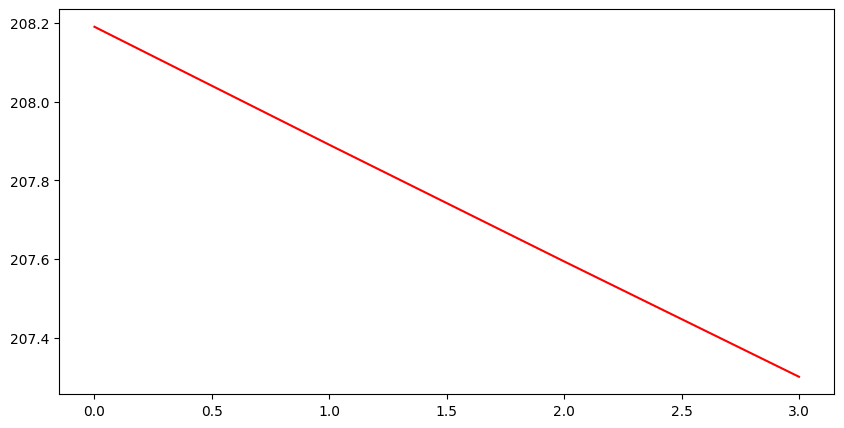

In [37]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(actual_stock_price_test_oriA[116:145], color = 'blue', label="Actual")
plt.plot(forecast_stock_price_test_oriF, color = 'red', label ="Predicted")